In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

In [6]:
# source folder
folder_name = 'Factset_Price_History_Downloads'
terms = [2, 3, 5, 7, 10, 20 , 30 ]

# iterate over the sub folders to access the files
# yr_files = { f'{term}yr': os.listdir(f'{folder_name}/us_{term}yr') for term in terms }
#
all_dfs = {}
all_by_yr = None
for term in terms:
    # start with the first df
    all_by_yr = pd.read_excel(f'{folder_name}/us_{term}yr/' + yr_files[f"{term}yr"][0], skiprows=2)
    all_by_yr.drop(columns = [ 'Composite'], inplace=True)
    all_by_yr.sort_values(by='Date', inplace = True)

    ## concat the rest of the dfs.
    for file in yr_files[f"{term}yr"][1:]:
      df = pd.read_excel(f'{folder_name}/us_{term}yr/{file}', skiprows=2)
      df.dropna(how='all', inplace=True)
      df.sort_values(by='Date', inplace=True)
      df.drop(columns = ['Date', 'Composite'], inplace=True)
      all_by_yr= pd.concat([all_by_yr, df], axis = 1)
      df = None

    all_dfs[f"{term}yr"] = all_by_yr
    all_by_yr = None

FileNotFoundError: [Errno 2] No such file or directory: 'Factset_Price_History_Downloads/us_2yr'

In [7]:
# get the CUSIPs
page_size   = 100
page_number = 1
url = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/auctions_query'

def get_treasuries(url, params):
    '''
     Function to pull data CUSIP data from the US Treasury
    '''

    resp=requests.get( url = url, params=params)
    data_dict = json.loads(resp.text)
    if  data_dict.get('data') is None:
      return None
    df = pd.DataFrame(data_dict['data'])
    df.sort_values(by="auction_date", inplace=True)
    return df

def extract_cusip(text):
    '''
     Function to extract the cusip from the column name
    '''
    substr = re.search(r'\((.+)\)',text )
    if substr:
        val= substr.group(1) # Extract the matched substring
        return val

    return None

In [8]:
processed_dfs = {}


for term in terms:
    ## Using 252 and the number of trading days + 20 days as a buffer for any unusual years
    ## Capturing the length of all non-nan values for each CUSIP's Column then recording the index of the column
    length_issues_idxs  = np.argwhere(len(all_dfs[f'{term}yr']) - all_dfs[f'{term}yr'].isna().sum().values > term * 252 + 20  )
    length_issues_idxs  = np.array( [ x[0] for x in length_issues_idxs])
    affected_cusips     = [extract_cusip(t) for t in list(all_dfs[f'{term}yr'].iloc[: , length_issues_idxs[ 1:]].columns)]
    params = { 'fields': 'cusip,security_term,security_type,issue_date,auction_date',
                  'filter': f'cusip:in:({",".join(affected_cusips)})',
                  'page[number]' : f'{page_number}',
                  'page[size]'   : f'{page_size}'
            }


    if len(length_issues_idxs) > 1 :
        issues_df = get_treasuries(url, params)
        issues_df.sort_values(by=['cusip', 'issue_date'])

        #Exclude any CUSIP that started before 2000. We will keep the time series that started after 2000.
        cusips_filter   = issues_df['cusip'][issues_df.issue_date < '2000-01-01']
        affected_cusips = issues_df['cusip'][~issues_df.cusip.isin( cusips_filter)].drop_duplicates().values
        print('Affected Cusips : ', affected_cusips)
        #Save for future reference
        issues_df.to_csv(f'Factset_Price_History_Reused_Cusips/us_treasuries/reused_cusips_{term}yr.csv', index=False)

    #Drop The CUSIP from the shorter length DataFrame

    mask = []
    for i, col  in enumerate(all_dfs[f'{term}yr'].iloc[:, 1:].columns):
      for cusip in affected_cusips:
          if f'({cusip})' in col:
            mask.append(i)
    print('Number of affected cusips:' , len(mask))
    cols_ser = pd.Series(all_dfs[f'{term}yr'].iloc[:, 1:].columns)
    cols_to_drop = cols_ser.iloc[mask].values
    df = all_dfs[f'{term}yr'].drop(columns= cols_to_drop)
    processed_dfs[f'{term}yr'] = df

KeyError: '2yr'

In [11]:
processed_dfs.keys()

dict_keys([])

In [11]:
processed_dfs['2yr']

,Date,United States Treasury Notes 0.25% 30-SEP-2023 (91282CDA6),United States Treasury Notes 0.125% 31-AUG-2023 (91282CCU3),United States Treasury Notes FRN 31-JUL-2023 (91282CCQ2),United States Treasury Notes 0.125% 31-JUL-2023 (91282CCN9),United States Treasury Notes 0.125% 30-JUN-2023 (91282CCK5),United States Treasury Notes 0.125% 31-MAY-2023 (91282CCD1),United States Treasury Notes FRN 30-APR-2023 (91282CBY6),United States Treasury Notes 0.125% 30-APR-2023 (91282CBX8),United States Treasury Notes 0.125% 31-MAR-2023 (91282CBU4),...,Government of the United States of America 5.75% 31-OCT-2002 (9128273L4),Government of the United States of America 6.0% 30-SEP-2002 (9128276L1),Government of the United States of America 6.125% 31-AUG-2002 (9128276K3),Government of the United States of America 6.25% 31-JUL-2002 (9128276H0),Government of the United States of America 6.375% 30-JUN-2002 (9128276F4),Government of the United States of America 6.625% 31-MAY-2002 (9128276E7),Government of the United States of America 6.375% 30-APR-2002 (9128276C1),Government of the United States of America 6.5% 31-MAR-2002 (9128276B3),Government of the United States of America 6.5% 28-FEB-2002 (9128276A5),Government of the United States of America 6.375% 31-JAN-2002 (9128275X6)
0,1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6417,2025-07-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6418,2025-07-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6419,2025-07-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6420,2025-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# load the fred data
df_fred = pd.read_parquet("FRED_Data/fred_raw.parquet")
df_fred.head()

FileNotFoundError: [Errno 2] No such file or directory: 'FRED_Data/fred_raw.parquet'

In [2]:
symbols = [
    "FEDFUNDS", "DGS10", "T5YIE", "T10YIE", "T10Y3M", "THREEFYTP10", "REAINTRATREARAT10Y", "VIXCLS", "EFFR", "CPILFESL",
    "USEPUINDXD", "GEPUCURRENT", 'DFII10', 'DGS10', 'DTWEXBGS', 'DCOILWTICO', 'DGS2', 'DGS5',
]

fred_series = {
    'T5YIE': '5_Year_Inflation_Expectation',
    'T10YIE': '10_Year_Inflation_Expectation',
    'T10Y3M': '10_Year_3_Year_Spread',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'THREEFYTP10': '10_Year_Term_Premium',
    'REAINTRATREARAT10Y': '10yr_real_intrest',
    # 'EFFR': 'Effective_Fed_Funds_Rate_Daily',
    'CPILFESL': 'CPI_Core',
    'USEPUINDXD': 'Economic_Policy_Uncertainty_US',
    'GEPUCURRENT': 'Global_EPU_Index',
    'REAINTRATREARAT10Y': 'Real_10-Year_Yield',
    'DFII10': '10_Year_TIPS_Yield',
    'DGS10': '10_Year_Treasury_Yield',
    'DTWEXBGS': 'Dollar_Index',
    'DCOILWTICO': 'Crude_Oil_Price_WTI',
    'DGS2': '2_Year_Treasury_Yield',
    'DGS5': '5_Year_Treasury_Yield',
    'WTISPLC': 'WTI_Spot_price',
    'INDPRO': 'Industrial_Production',
    'IPMAN': 'Manufacturing_Production',
    'CBBTCUSD': 'Bitcoin_spot_price',
    'M2SL': 'Money_supply',
    'GVZCLS': 'Gold_Volatility_Index',
    'M14062USM027NNBR': 'Gold_Reserves_US',
    'TRESEGUSM052N': 'Gold_Reserves_World',
    'SP500': 'S&P500_Index',
    'U2RATE': 'Unemployment_Rate_US',
    'FDHBFRBN': 'Federal_Debt_Hold_by_Fed',
    'T10Y2Y': '10yr_2yr_spread',
    'T10YIE': '10_year_breakeven_inflation',
    'T5YFF': '5_year_treasury_fed_funds',
    'TB3SMFFM': '3yr_t_bill_spread',
    'MORTGAGE30US': '30yr_mortgage_rate',
    'MORTGAGE15US': '15yr_mortgage_rate',
    'OBMMIFHA30YF': '30yr_fixed_fha',
    'TB3MS': '3mth_treasury',
    'EXUSEU': 'us_euro_exchange_rate',
    'EXJPUS': 'japan_usd_exchange_rate',
    'EXCHUS': 'china_usd_exchange_rate',
    'EXCAUS': 'canada_usd_exchange_rate',
    'EXUSUK': 'uk_usd_exchange_rate',
    'EXKOUS': 'skorea_usd_exchange_rate',
    'EXBZUS': 'brazil_usd_exchange_rate',
    'EXMXUS': 'mex_usd_exchange_rate',
    'EXINUS': 'india_usd_exchange_rate',
    'EXUSAL': 'aus_usd_exchange_rate',
    'EXSDUS': 'swd_usd_exchange_rate',
    'EXSGUS': 'sweden_usd_exchange_rate',
    'EXSIUS': 'singapore_usd_exchange_rate',
    'EXSFUS': 'safrice_usd_exchange_rate',
    'DTWEXBGS': 'us_dollar_index',
    'RTWEXBGS': 'broad_dollar_index',
    'SWPT': 'cc_bank_liquidity_swps',
    'WRESBAL': 'liabilities_reserve_bank',
    'BORROW': 'total_borrowing',
    'TOTRESNS': 'reserves_deposit_institutions',
    'ADPWINDINFONERSA': 'employement_information',
    'ADPWINDPROBUSNERSA': 'unemployment_business',
    'TENEXPCHAREARISPRE': 'real_risk_premium',
    'STLPPM': 'price_pressure',
    'TENEXPCHAINFRISPRE': 'inflation_risk_premium',
    'IR': 'import_price_index',
    'IR14270': 'import_price_index_non_money',
    'IR10000': 'import_price_oil',
    'IQ12260': 'export_non_money',
    'IQ': 'export_price_index',
    'MVGFD027MNFRBDAL': 'market_val_fed_debt',
    'MTSMFBP133FMS': 'borrow_public',
}

fred_series_transformation = {
    '5_Year_Inflation_Expectation': True,
    '10_Year_Inflation_Expectation': True,
    '10_Year_3_Year_Spread': True,
    'Fed_Funds_Rate': True,
    '10_Year_Term_Premium': True,
    '10yr_real_intrest': True,
    # 'Effective_Fed_Funds_Rate_Daily',
    'CPI_Core': False,
    'Economic_Policy_Uncertainty_US': False,
    'Global_EPU_Index': False,
    'Real_10-Year_Yield': True,
    '10_Year_TIPS_Yield': True,
    '10_Year_Treasury_Yield': True,
    'Dollar_Index': False,
    'Crude_Oil_Price_WTI': False,
    '2_Year_Treasury_Yield': True,
    '5_Year_Treasury_Yield': True,
    'WTI_Spot_price': False,
    'Industrial_Production': False,
    'Manufacturing_Production': False,
    'Bitcoin_spot_price': False,
    'Money_supply': False,
    'Gold_Volatility_Index': False,
    'Gold_Reserves_US': False,
    'TRESEGUSM052N': False,
    'S&P500_Index': False,
    'Unemployment_Rate_US': True,
    'Federal_Debt_Hold_by_Fed': False,
    'Gold_Reserves_World': False

}
# df_fred[df_fred['id'].isin(symbols)]

### 📊 Macroeconomic Indicators and FRED Symbols for U.S. Government Bonds

| **Indicator**                          | **FRED Symbol**         | **Description**                                      |
|---------------------------------------|--------------------------|------------------------------------------------------|
| Fed Funds Effective Rate              | `FEDFUNDS`              | Benchmark short-term interest rate                   |
| 10-Year Treasury Yield                | `DGS10`                 | Long-term yield signal                               |
| 5-Year Breakeven Inflation            | `T5YIE`                 | 5-year inflation expectation                         |
| 10-Year Breakeven Inflation           | `T10YIE`                | 10-year inflation expectation                        |
| Yield Curve Spread (10Y minus 3M)     | `T10Y3M`                | Indicator of growth/inversion                        |
| 10-Year Term Premium                  | `THREEFYTP10`           | Premium over short rates for duration risk           |
| 10-Year Real Interest Rate Estimate   | `REAINTRATREARAT10Y`    | Real rate adjusted for inflation expectations        |


In [3]:
# get the series
# Pull data from FRED and store in a dictionary
start = datetime(1950, 1, 1)
end = datetime(2025, 7, 28)
data = {}
for symbol, label in fred_series.items():
    try:
        data[label] = web.DataReader(symbol, 'fred', start, end)
    except Exception as e:
        print(f"Failed to fetch {label} ({symbol}): {e}")
df_all = pd.concat(data.values(), axis=1)
df_all.columns = data.keys()

Failed to fetch sweden_usd_exchange_rate (EXSGUS): Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=EXSGUS
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="preconnect" href="https://fonts.g

In [4]:
df_all.head()

,5_Year_Inflation_Expectation,10_year_breakeven_inflation,10_Year_3_Year_Spread,Fed_Funds_Rate,10_Year_Term_Premium,Real_10-Year_Yield,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,10_Year_TIPS_Yield,...,real_risk_premium,price_pressure,inflation_risk_premium,import_price_index,import_price_index_non_money,import_price_oil,export_non_money,export_price_index,market_val_fed_debt,borrow_public
DATE,,,,,,,,,,,,,,,,,,,,,
1950-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,262.8,NaN
1950-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261.9,NaN
1950-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.7,NaN
1950-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.2,NaN
1950-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.8,NaN


In [5]:
df_all.describe()

,5_Year_Inflation_Expectation,10_year_breakeven_inflation,10_Year_3_Year_Spread,Fed_Funds_Rate,10_Year_Term_Premium,Real_10-Year_Yield,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,10_Year_TIPS_Yield,...,real_risk_premium,price_pressure,inflation_risk_premium,import_price_index,import_price_index_non_money,import_price_oil,export_non_money,export_price_index,market_val_fed_debt,borrow_public
count,5646.000000,5646.000000,10894.000000,853.000000,8878.000000,523.000000,823.000000,14819.000000,343.000000,5646.000000,...,523.000000,427.000000,523.000000,465.000000,384.000000,442.000000,416.000000,461.000000,907.000000,1.870000e+02
mean,1.945073,2.098045,1.560632,4.607057,0.830703,2.421780,140.931255,113.982513,146.190087,0.956173,...,1.243983,0.336339,0.412664,113.126882,37.985677,189.291629,36.436058,114.567679,6825.297574,1.155986e+05
std,0.568776,0.397924,1.250882,3.552996,0.745530,1.827435,87.652677,89.569672,83.112761,1.008433,...,0.086144,0.303532,0.076969,19.638809,25.630487,119.551139,25.239456,18.574033,9087.664572,1.737979e+05
min,-2.240000,0.040000,-1.890000,0.050000,-0.658700,-0.407134,28.500000,3.320000,47.857995,-1.190000,...,1.019973,0.000021,-0.124607,75.000000,9.500000,33.200000,9.900000,82.400000,253.800000,-1.154170e+05
25%,1.630000,1.850000,0.590000,1.880000,0.250850,0.927522,47.400000,57.705000,83.232528,0.260000,...,1.182802,0.061147,0.380864,95.500000,14.100000,77.350000,14.400000,98.800000,339.000000,1.188222e+04
50%,1.990000,2.200000,1.610000,4.330000,0.759650,2.082461,140.900000,90.290000,120.577093,0.910000,...,1.232886,0.217099,0.418095,113.300000,35.150000,171.300000,30.650000,110.400000,2436.300000,7.861575e+04
75%,2.340000,2.360000,2.560000,6.140000,1.359500,3.579433,215.180000,141.610000,185.271645,1.840000,...,1.292929,0.627563,0.458468,128.100000,55.650000,282.975000,51.225000,126.700000,8710.950000,1.582815e+05
max,3.590000,3.020000,5.180000,19.100000,2.515700,7.656648,328.656000,1026.380000,628.479560,3.150000,...,1.532624,0.980798,0.588369,148.500000,129.000000,491.000000,129.100000,166.700000,34788.500000,1.386528e+06


In [6]:
df_all.to_parquet("macro_economical_data(2).parquet")

In [15]:
for key, value in processed_dfs.items():
    print(f"persisting -> {key}")
    try:
        value.to_parquet(f"{key}.parquet")
    except Exception as e:
        print(f"Failed to persist {key}: {e}")

persisting -> 2yr
persisting -> 3yr
persisting -> 5yr
Failed to persist 5yr: Duplicate column names found: ['Date', 'United States Treasury Notes 1.125% 28-FEB-2021 (912828P87)', 'United States Treasury Notes 1.375% 31-JAN-2021 (912828N89)', 'United States Treasury Notes 1.75% 31-DEC-2020 (912828N48)', 'United States Treasury Notes 1.625% 30-NOV-2020 (912828M98)', 'United States Treasury Notes 1.375% 31-OCT-2020 (912828L99)', 'United States Treasury Notes 1.375% 30-SEP-2020 (912828L65)', 'United States Treasury Notes 1.375% 31-AUG-2020 (912828L32)', 'United States Treasury Notes 1.375% 30-APR-2020 (912828K58)', 'United States Treasury Notes 0.125% 15-APR-2020 (912828K33)', 'United States Treasury Notes 1.375% 31-MAR-2020 (912828J84)', 'United States Treasury Notes 1.375% 29-FEB-2020 (912828J50)', 'United States Treasury Notes 1.375% 31-JUL-2018 (912828VQ0)', 'United States Treasury Notes 1.375% 30-JUN-2018 (912828VK3)', 'United States Treasury Notes 1.0% 31-MAY-2018 (912828VE7)', 'Unit

In [9]:
def check_daily(df: pd.DataFrame):
    """
    Function to check if the dataframe is daily data
    """
    # Check if the index is a datetime index
    values = df['DATE'].values[:2]
    # get the daily difference beween the first two dates
    diff_val = values[1] - values[0]
    daily_diff = diff_val / np.timedelta64(1, 'D')
    if daily_diff < 27:
        return "daily"
    elif daily_diff <= 32:
        return "monthly"
    elif daily_diff <= 100:
        return "quarterly"
    else:
        return "annually"

# read in alll the persisted data
def read_persisted_data(terms: list[int]):
    """
    Function to read all the persisted data from parquet files
    """
    processed_dfs = {}
    for term in terms:
        try:
            df = pd.read_parquet(f"{term}yr.parquet")
            processed_dfs[term] = df
        except Exception as e:
            print(f"Failed to read {term}yr data: {e}")
    return processed_dfs

terms = [2, 3, 20, 30]
processed_dfs = read_persisted_data(terms=terms)
print(processed_dfs.keys())


dict_keys([2, 3, 20, 30])


In [11]:

# processed_dfs[2].head()

# Stack all the dataframes in processed_dfs into a single dataframe by bond term
full_bonds_dfs = []
for key, value in processed_dfs.items():
    term_bond_dfs = []
    for col in tqdm(value.columns, desc=f"Processing {key}yr bonds", total=len(value.columns)):
        if col == 'Date':
            continue  # Skip the Date column
        df_tmp = value[['Date', col]].dropna()
        df_tmp.rename(columns={col: f'price'}, inplace=True)
        df_tmp['bond'] = col
        df_tmp['term'] = key
        term_bond_dfs.append(df_tmp)
    full_bonds_dfs.append(pd.concat(term_bond_dfs, axis=0, ignore_index=True))
# concat the bonds dataframes
full_bonds_df = pd.concat(full_bonds_dfs, axis=0, ignore_index=True)
full_bonds_df.head()

Processing 30yr bonds: 100%|██████████| 88/88 [00:00<00:00, 397.14it/s]


,Date,price,bond,term
0,2021-09-27,99.883,United States Treasury Notes 0.25% 30-SEP-2023...,2
1,2021-09-28,99.887,United States Treasury Notes 0.25% 30-SEP-2023...,2
2,2021-09-29,99.902,United States Treasury Notes 0.25% 30-SEP-2023...,2
3,2021-09-30,99.918,United States Treasury Notes 0.25% 30-SEP-2023...,2
4,2021-10-01,99.969,United States Treasury Notes 0.25% 30-SEP-2023...,2


In [13]:
full_bonds_df.shape
# perstist the full bonds dataframe
full_bonds_df.to_parquet("all_bonds_data.parquet")

In [9]:
# load the macroeconomic data
df_macro = pd.read_parquet("macro_economical_data(2).parquet")
df_macro.head()

,5_Year_Inflation_Expectation,10_year_breakeven_inflation,10_Year_3_Year_Spread,Fed_Funds_Rate,10_Year_Term_Premium,Real_10-Year_Yield,CPI_Core,Economic_Policy_Uncertainty_US,Global_EPU_Index,10_Year_TIPS_Yield,...,real_risk_premium,price_pressure,inflation_risk_premium,import_price_index,import_price_index_non_money,import_price_oil,export_non_money,export_price_index,market_val_fed_debt,borrow_public
DATE,,,,,,,,,,,,,,,,,,,,,
1950-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,262.8,NaN
1950-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261.9,NaN
1950-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.7,NaN
1950-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.2,NaN
1950-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.8,NaN


In [10]:
# REset the index
df_macro.reset_index(inplace=True)
# create a seperate dataframe for the macroeconomic columns then calcualte the log returns for each column
macro_data = {}
# inf_columns = [
#     '10_Year_3_Year_Spread', '10_Year_Term_Premium', '10_Year_TIPS_Yield'
# ]
for col in df_macro.columns:
    if col == 'DATE':
        continue  # Skip the DATE column, we will use it as an index
    # drop the null values
    df_tmp = df_macro[['DATE', col]].dropna()
    # multiply the column by 100 if it is a percentage
    # if fred_series_transformation[col]:
    #     df_tmp[col] = df_tmp[col] * 100
      # Adding
    # calculate the log returns
    if df_tmp[col].min() <= 0:
        # find the constant to add that makes the min value 1
        constant = abs(df_tmp[col].min()) + 1
        df_tmp[col] = df_tmp[col] + constant

    df_tmp[f'{col}_log_return'] = np.log(df_tmp[col] / df_tmp[col].shift(1))
    try:
        if check_daily(df_tmp) == "daily":
            df_tmp['Month'] = pd.to_datetime(df_tmp['DATE']).dt.to_period('M').dt.to_timestamp()
            df_tmp = df_tmp.groupby('Month').agg({f'{col}_log_return': 'sum',
                                          f'{col}': ['max', 'min']})
            df_tmp.columns = ['_'.join(col).strip() for col in df_tmp.columns.values]
            df_tmp['DATE'] = df_tmp.index
            df_tmp[f'{col}_log_return_sum_discretized'] = np.where(df_tmp[f'{col}_log_return_sum'] > 0, 'Increase', 'Decrease')
            df_tmp[f'{col}_max_min_return_diff'] = np.log(df_tmp[f'{col}_max'] / df_tmp[f'{col}_min'])
        else:
            # discritize the return values into up, or down
            df_tmp[f'Month'] = df_tmp['DATE']
            df_tmp[f'{col}_log_return_discretized'] = np.where(df_tmp[f'{col}_log_return'] > 0, 'Increase', 'Decrease')
            df_tmp.rename(columns={f'{col}_log_return': f'{col}_log_return_sum'}, inplace=True)
    # store the dataframe in the macro_data dictionary
    except Exception as e:
        print(f"Error processing {col}: {e}")
        continue
    macro_data[col] = df_tmp.reset_index()

macro_data.keys()

Error processing Gold_Reserves_US: index 1 is out of bounds for axis 0 with size 0


dict_keys(['5_Year_Inflation_Expectation', '10_year_breakeven_inflation', '10_Year_3_Year_Spread', 'Fed_Funds_Rate', '10_Year_Term_Premium', 'Real_10-Year_Yield', 'CPI_Core', 'Economic_Policy_Uncertainty_US', 'Global_EPU_Index', '10_Year_TIPS_Yield', '10_Year_Treasury_Yield', 'us_dollar_index', 'Crude_Oil_Price_WTI', '2_Year_Treasury_Yield', '5_Year_Treasury_Yield', 'WTI_Spot_price', 'Industrial_Production', 'Manufacturing_Production', 'Bitcoin_spot_price', 'Money_supply', 'Gold_Volatility_Index', 'Gold_Reserves_World', 'S&P500_Index', 'Unemployment_Rate_US', 'Federal_Debt_Hold_by_Fed', '10yr_2yr_spread', '5_year_treasury_fed_funds', '3yr_t_bill_spread', '30yr_mortgage_rate', '15yr_mortgage_rate', '30yr_fixed_fha', '3mth_treasury', 'us_euro_exchange_rate', 'japan_usd_exchange_rate', 'china_usd_exchange_rate', 'canada_usd_exchange_rate', 'uk_usd_exchange_rate', 'skorea_usd_exchange_rate', 'brazil_usd_exchange_rate', 'mex_usd_exchange_rate', 'india_usd_exchange_rate', 'aus_usd_exchange_r

In [11]:
for col in macro_data.keys():
    print(f"Column: {col}")
    print("#################################################")
    print(macro_data[col].describe())

# np.log(-100 / 100)

Column: 5_Year_Inflation_Expectation
#################################################
                               Month  \
count                            271   
mean   2014-04-01 11:41:24.132841216   
min              2003-01-01 00:00:00   
25%              2008-08-16 12:00:00   
50%              2014-04-01 00:00:00   
75%              2019-11-16 00:00:00   
max              2025-07-01 00:00:00   
std                              NaN   

       5_Year_Inflation_Expectation_log_return_sum  \
count                                   271.000000   
mean                                      0.000846   
min                                      -0.824175   
25%                                      -0.020840   
50%                                       0.003643   
75%                                       0.025850   
max                                       1.091923   
std                                       0.099247   

       5_Year_Inflation_Expectation_max  5_Year_Inflation_Expecta

In [33]:
macro_data['5_Year_Inflation_Expectation'].head()

,Month,5_Year_Inflation_Expectation_log_return_sum,5_Year_Inflation_Expectation_max,5_Year_Inflation_Expectation_min,DATE,5_Year_Inflation_Expectation_log_return_discretized,5_Year_Inflation_Expectation_max_min_return_diff
0,2003-01-01,0.040998,4.76,4.52,2003-01-01,Increase,0.051736
1,2003-02-01,0.053511,5.02,4.76,2003-02-01,Increase,0.053182
2,2003-03-01,-0.020244,5.11,4.81,2003-03-01,Decrease,0.060502
3,2003-04-01,-0.041760,4.90,4.69,2003-04-01,Decrease,0.043803
4,2003-05-01,-0.041355,4.74,4.47,2003-05-01,Decrease,0.058649


In [38]:
# def check_daily(df: pd.DataFrame):
#     """
#     Function to check if the dataframe is daily data
#     """
#     # Check if the index is a datetime index
#     values = df['DATE'].values[:2]
#     # get the daily difference beween the first two dates
#     diff_val = values[1] - values[0]
#     daily_diff = diff_val / np.timedelta64(1, 'D')
#     if daily_diff < 27:
#         return "daily"
#     elif daily_diff <= 32:
#         return "monthly"
#     elif daily_diff <= 100:
#         return "quarterly"
#     else:
#         return "annually"

In [12]:
processed_bonds = []
for key, value in tqdm(processed_dfs.items()):
    for col in value.columns:
        if col == 'Date':
            continue  # Skip the Date column
        # dropna values
        df_tmp = value[['Date', col]].dropna()
        df_tmp['Month'] = pd.to_datetime(df_tmp['Date']).dt.to_period('M').dt.to_timestamp()
        # calculate the log returns on the prices
        df_tmp[f'bond_log_return'] = np.log(df_tmp[col] / df_tmp[col].shift(1))
        df_tmp = df_tmp.groupby('Month').agg({'bond_log_return': 'sum',
                              f'{col}': ['max', 'min']})

        df_tmp.columns = ['_'.join(col).strip() for col in df_tmp.columns.values]
        df_tmp.rename(columns={
            'bond_log_return_sum': 'bond_log_return',
            f'{col}_min': 'bond_price_min',
            f'{col}_max': 'bond_price_max',
        }, inplace=True)
        df_tmp.reset_index(inplace=True)
        # aggregate the bond log returns by month
        # discritize the return values into up, or down
        df_tmp[f'return_label'] = np.where(df_tmp[f'bond_log_return'] > 0, 'Increase', 'Decrease')
        df_tmp[f'bond_max_min_return_diff'] = np.log(df_tmp[f'bond_price_max'] / df_tmp[f'bond_price_min'])
        df_tmp['DATE'] = df_tmp['Month']
        df_tmp["bond"] = col
        df_tmp['term'] = key
        for macro_col in macro_data.keys():
            if macro_col == 'index':
                continue
            # Check if the macroeconomic data is daily
            frequency = check_daily(macro_data[macro_col])
            if frequency == "daily":
                # merge on the Date column
                df_tmp = pd.merge(df_tmp, macro_data[macro_col], how='left', on='Month')
            else:
                # create for monthly data
                df_tmp = pd.merge(df_tmp, macro_data[macro_col], how='left', on='Month')
                # drob the date_y column
            df_tmp.drop(columns=['Month_y'], inplace=True, errors='ignore')
            df_tmp.rename(columns={'Month_x': 'Month'}, inplace=True)
            df_tmp.drop(columns=['DATE_y'], inplace=True, errors='ignore')
            df_tmp.rename(columns={'DATE_x': 'DATE'}, inplace=True)
            df_tmp.drop(columns=['index_y', 'index_x'], inplace=True, errors='ignore')

        processed_bonds.append(df_tmp)

df_processed = pd.concat(processed_bonds, axis=0, ignore_index=False)
df_processed.head()



100%|██████████| 4/4 [02:23<00:00, 35.91s/it]


,Month,bond_log_return,bond_price_max,bond_price_min,return_label,bond_max_min_return_diff,DATE,bond,term,5_Year_Inflation_Expectation_log_return_sum,...,export_price_index,export_price_index_log_return_sum,export_price_index_log_return_discretized,market_val_fed_debt,market_val_fed_debt_log_return_sum,market_val_fed_debt_log_return_discretized,index,borrow_public,borrow_public_log_return_sum,borrow_public_log_return_discretized
0,2021-09-01,0.000350,99.918,99.883,Increase,0.000350,2021-09-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,0.005231,...,142.8,0.002805,Increase,29595.5,-0.007262,Decrease,19616.0,145363.132782,0.536077,Increase
1,2021-10-01,-0.003168,99.969,99.574,Decrease,0.003959,2021-10-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,0.063995,...,145.5,0.018731,Increase,30048.2,0.015180,Increase,19646.0,472020.232076,1.177787,Increase
2,2021-11-01,0.000040,99.781,99.402,Increase,0.003806,2021-11-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,-0.014791,...,146.5,0.006849,Increase,30147.9,0.003313,Increase,19677.0,122929.877684,-1.345408,Decrease
3,2021-12-01,-0.003026,99.531,99.246,Decrease,0.002868,2021-12-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,0.011523,...,144.2,-0.015824,Decrease,30718.8,0.018760,Increase,19707.0,613756.940265,1.607985,Increase
4,2022-01-01,-0.006354,99.246,98.652,Decrease,0.006003,2022-01-01,United States Treasury Notes 0.25% 30-SEP-2023...,2,-0.008217,...,148.2,0.027361,Increase,30648.6,-0.002288,Decrease,19738.0,456401.195296,-0.296227,Decrease


In [13]:
df_processed.shape

(26159, 242)

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_17347/271401927.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_processed['Term'] = df_processed['term'].astype(str)  # Convert term to string for better plotting
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_17347/271401927.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_processed.reset_index(inplace=True)


Text(0.5, 0, 'Log Returns')

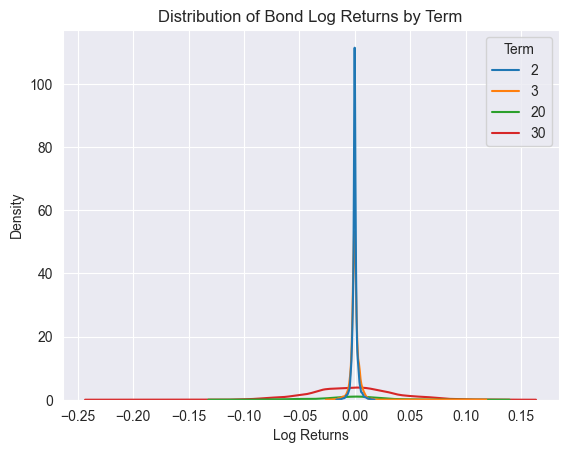

In [15]:
df_processed['Term'] = df_processed['term'].astype(str)  # Convert term to string for better plotting
df_processed.reset_index(inplace=True)
sns.kdeplot(df_processed, x='bond_log_return', hue='Term')
# hide the legend
plt.title("Distribution of Bond Log Returns by Term")
plt.xlabel("Log Returns")


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_11939/914074465.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)


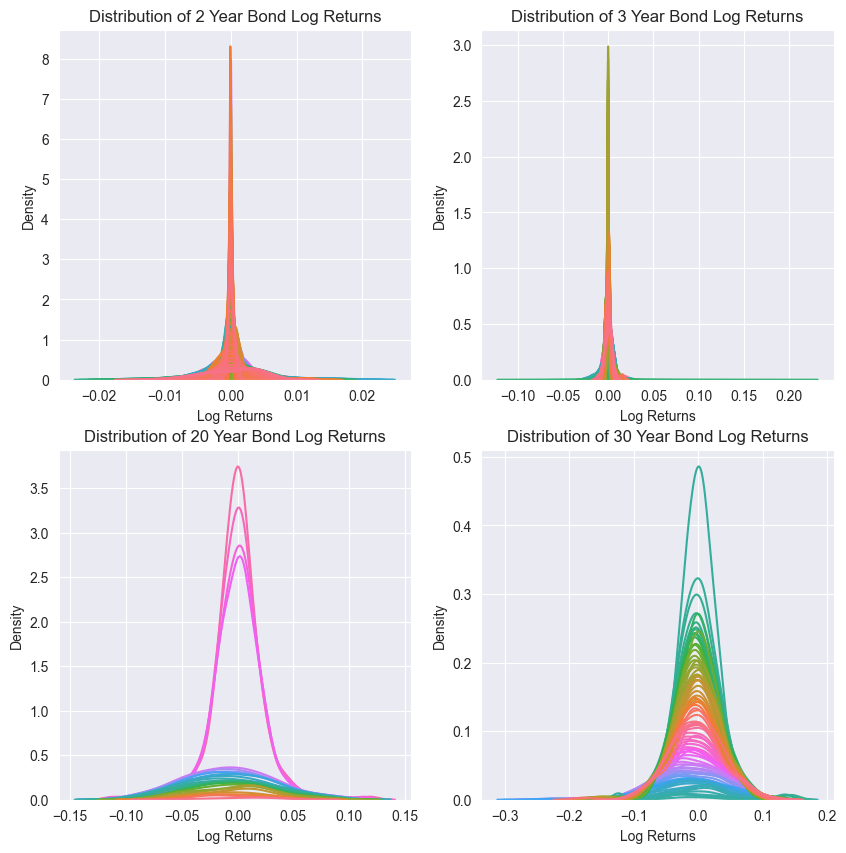

In [37]:
# create a 2 by 2 subplot for each term
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
i = 0
for term in terms:
    df_term = df_processed[df_processed['Term'] == f"{term}"]
    sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f"Distribution of {term} Year Bond Log Returns")
    axes[i].set_xlabel("Log Returns")
    axes[i].set_ylabel("Density")
    i += 1
    # axes[i].legend(title='Bond')
    # plt.show()

In [16]:
df_processed.to_parquet(f"processed_bonds_macro_lag1(4).parquet")

Text(0.5, 0, 'Number of Observations')

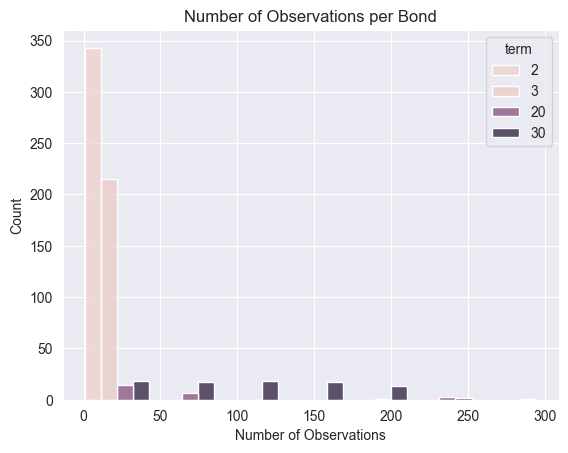

In [91]:
row_count = df_processed[["term", "bond"]].value_counts().to_frame().reset_index()
sns.histplot(row_count, x='count', hue="term", binwidth=40, multiple="dodge").set_title(f"Number of Observations per Bond")
plt.xlabel("Number of Observations")

In [39]:
df_processed.columns

Index(['level_0', 'Month', 'bond_log_return', 'bond_price_max',
       'bond_price_min', 'return_label', 'bond_max_min_return_diff', 'DATE',
       'bond', 'term',
       ...
       'S&P500_Index_log_return_discretized',
       'S&P500_Index_max_min_return_diff', 'Unemployment_Rate_US',
       'Unemployment_Rate_US_log_return_sum',
       'Unemployment_Rate_US_log_return_discretized', 'index',
       'Federal_Debt_Hold_by_Fed', 'Federal_Debt_Hold_by_Fed_log_return_sum',
       'Federal_Debt_Hold_by_Fed_log_return_discretized', 'Term'],
      dtype='object', length=115)

In [ ]:

# Create
